In [1]:
#dataframes
import pandas as pd
import h5py

import sys
sys.path.append('../../')
import odor_statistics_lib as osm

#suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.TimeSeries = pd.Series 

#math
import numpy as np
import math as m
from scipy.spatial.distance import cdist
from scipy import signal

#plots
import pylab as plt
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib import colors
import matplotlib
from figurefirst import FigureLayout,mpl_functions
import figurefirst
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import make_axes_locatable # for colorbar
import seaborn as sns

sns.set_style("whitegrid")
import figurefirst as fifi
from IPython.display import display,SVG

#misc
import fly_plot_lib.plot as fpl
import itertools
np.set_printoptions(suppress=True)

FS=7
dir = '~/DataAnalysis/data/Sprints/HighRes/'

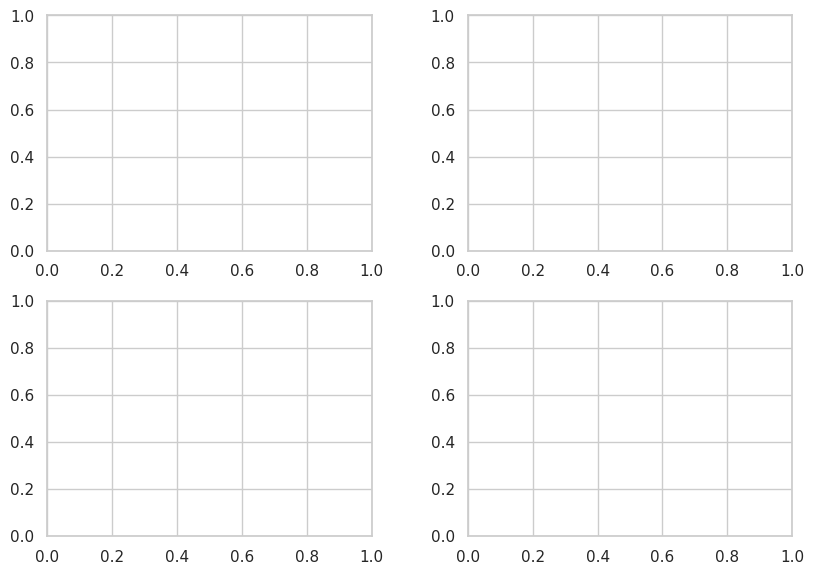

In [2]:
layout = fifi.svg_to_axes.FigureLayout('../../../../Figure/review/errorAnalysis.svg',
                                           autogenlayers=True, make_mplfigures=True, hide_layers=[])

### KLM FIGURE

In [3]:
median_error_df = pd.read_hdf('~/DataAnalysis/data/Sprints/HighRes/review/median_error_klm.h5')

In [4]:
ax=layout.axes[('fig','ax1')]

lw=0.5
msize=3

ax.plot(median_error_df.threshold,median_error_df.median_error_hws,c ='b', label='HWS',rasterized=True)
ax.plot(median_error_df.threshold,median_error_df.median_error_lws,c='g', label='LWS', rasterized=True)
ax.plot(median_error_df.threshold,median_error_df.median_error_forest,c='purple', label='Forest', rasterized=True)

ax.grid(False)
ax.set_rasterization_zorder(-20)

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left':4,'bottom':5}, 
                            smart_bounds=True,
                            xticks=[1,2,4,6,8],
                            yticks = [2,9],
                            linewidth=0.5)
ax.set_xticklabels([1,2,4,6,8])
# ax.set_yticklabels([])

ax.set_ylabel('median error, m')
ax.yaxis.set_label_coords(-0.04, 0.5)

ax.set_xlabel('Odor Threshold, a.u.')
ax.xaxis.set_label_coords(0.5, -.1)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig'], 'fig', cleartarget=True)
layout.write_svg('../../../../Figure/review/errorAnalysis.svg')

### R2 STAT FIGURE

In [5]:
individual_r2_df = pd.read_hdf('~/DataAnalysis/data/Sprints/HighRes/review/individual_r2_hws.h5')
ax=layout.axes[('fig','ax2')]

lw=0.5
msize=3


ax.plot(individual_r2_df.index, individual_r2_df.threshold_1, label='odor> 1 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_2, label='odor> 2 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_4, label='odor> 4 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_6, label='odor> 6 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_8, label='odor> 8 a.u.', rasterized=True)

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left':4,'bottom':5}, 
                            smart_bounds=True,
                            xticks=[0,1,2,3,4],
                            yticks = [0,0.8],
                            linewidth=0.5)

ax.grid(False)
ax.set_rasterization_zorder(-20)

ax.set_xticklabels(['$\mu(WC)$','$\mu(WF)$','$\mu(WD)$','$\mu(WMA)$','$\mu(WSD)$'])
ax.set_ylabel('R-squared')
ax.yaxis.set_label_coords(-0.04, 0.5)
ax.legend(loc='best')
# ax.set_xlabel('Odor Threshold, a.u.')
# ax.xaxis.set_label_coords(0.5, -.1)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig'], 'fig', cleartarget=True)
layout.write_svg('../../../../Figure/review/errorAnalysis.svg')

In [6]:
individual_r2_df = pd.read_hdf('~/DataAnalysis/data/Sprints/HighRes/review/individual_r2_lws.h5')
ax=layout.axes[('fig','ax3')]

lw=0.5
msize=3


ax.plot(individual_r2_df.index, individual_r2_df.threshold_1, label='odor> 1 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_2, label='odor> 2 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_4, label='odor> 4 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_6, label='odor> 6 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_8, label='odor> 8 a.u.', rasterized=True)

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left':4,'bottom':5}, 
                            smart_bounds=True,
                            xticks=[0,1,2,3,4],
                            yticks = [0,0.8],
                            linewidth=0.5)

ax.grid(False)
ax.set_rasterization_zorder(-20)

ax.set_xticklabels(['$\mu(WC)$','$\mu(WF)$','$\mu(WD)$','$\mu(WMA)$','$\mu(WSD)$'])
ax.set_ylabel('R-squared')
ax.yaxis.set_label_coords(-0.04, 0.5)
# ax.legend(loc='best')
# ax.set_xlabel('Odor Threshold, a.u.')
# ax.xaxis.set_label_coords(0.5, -.1)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig'], 'fig', cleartarget=True)
layout.write_svg('../../../../Figure/review/errorAnalysis.svg')

In [7]:
individual_r2_df = pd.read_hdf('~/DataAnalysis/data/Sprints/HighRes/review/individual_r2_forest.h5')
ax=layout.axes[('fig','ax4')]

lw=0.5
msize=3


ax.plot(individual_r2_df.index, individual_r2_df.threshold_1, label='odor> 1 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_2, label='odor> 2 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_4, label='odor> 4 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_6, label='odor> 6 a.u.', rasterized=True)
ax.plot(individual_r2_df.index, individual_r2_df.threshold_8, label='odor> 8 a.u.', rasterized=True)

mpl_functions.adjust_spines(ax,['left','bottom'],
                            spine_locations={'left':4,'bottom':5}, 
                            smart_bounds=True,
                            xticks=[0,1,2,3,4],
                            yticks = [0,0.8],
                            linewidth=0.5)

ax.grid(False)
ax.set_rasterization_zorder(-20)

ax.set_xticklabels(['$\mu(WC)$','$\mu(WF)$','$\mu(WD)$','$\mu(WMA)$','$\mu(WSD)$'])
ax.set_ylabel('R-squared')
ax.yaxis.set_label_coords(-0.04, 0.5)
# ax.legend(loc='best')
# ax.set_xlabel('Odor Threshold, a.u.')
# ax.xaxis.set_label_coords(0.5, -.1)

figurefirst.mpl_functions.set_fontsize(ax, FS)
layout.append_figure_to_layer(layout.figures['fig'], 'fig', cleartarget=True)
layout.write_svg('../../../../Figure/review/errorAnalysis.svg')